In [1]:
import jax

from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import BackwardProbModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.model import PhysicalModel
from gigalens.jax.profiles.light import shapelets
from gigalens.jax.profiles.mass import epl, shear

import corner as corner
import tensorflow_probability.substrates.jax as tfp
from jax import numpy as jnp
import time
import numpy as np
import optax
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import norm, kstest
from astropy.visualization import simple_norm
tfd = tfp.distributions

import blackjax
import sys
sys.path.append('../')

import os
sys.path.insert(0, f'{os.environ['HOME']}/gigalens/src/gigalens_2/jax')
from profiles.light import sersic

2026-04-03 15:37:55.554570: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775255875.569285 1355981 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775255875.574174 1355981 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775255875.588029 1355981 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775255875.588040 1355981 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775255875.588043 1355981 computation_placer.cc:177] computation placer alr

In [2]:
lens_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                theta_E=tfd.LogNormal(jnp.log(2.5), 0.25),
                gamma=tfd.TruncatedNormal(2, 0.25, 1, 2.7),
                e1=tfd.Normal(0, 0.1),
                e2=tfd.Normal(0, 0.1),
                center_x=tfd.Normal(0, 0.05),
                center_y=tfd.Normal(0, 0.05),
            )
        ),
        tfd.JointDistributionNamed(
            dict(gamma1=tfd.Normal(0, 0.05), gamma2=tfd.Normal(0, 0.05))
        ),
    ]
)
lens_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.4), 0.2),
                n_sersic=tfd.Uniform(0.5, 5),
                e1=tfd.TruncatedNormal(0, 0.15, -0.3, 0.3),
                e2=tfd.TruncatedNormal(0, 0.15, -0.3, 0.3),
                center_x=tfd.Normal(3.5, 0.05),
                center_y=tfd.Normal(0.1, 0.05),
            ) #nearby 1
        ),
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.4), 0.2),
                n_sersic=tfd.Uniform(0.5, 5),
                e1=tfd.TruncatedNormal(0, 0.15, -0.3, 0.3),
                e2=tfd.TruncatedNormal(0, 0.15, -0.3, 0.3),
                center_x=tfd.Normal(3.5, 0.05),
                center_y=tfd.Normal(0.1, 0.05),
            )#nearby 2
        ),
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(1.0), 0.15),
                n_sersic=tfd.Uniform(0.5, 10),
                e1=tfd.Normal(0, 0.15),
                e2=tfd.Normal(0, 0.15),
                center_x=tfd.Normal(0, 0.05),
                center_y=tfd.Normal(0, 0.05),
            )#lens 1
        ),
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(1.0), 0.15),
                n_sersic=tfd.Uniform(0.5, 10),
                e1=tfd.Normal(0, 0.15),
                e2=tfd.Normal(0, 0.15),
                center_x=tfd.Normal(0, 0.1),
                center_y=tfd.Normal(0, 0.1),
            )#lens 2
        )
    ]
)

source_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.25), 0.15),
                n_sersic=tfd.Uniform(0.5, 6),
                e1=tfd.Normal(0, 0.15),
                e2=tfd.Normal(0, 0.15),
                center_x=tfd.Normal(0, 0.1),
                center_y=tfd.Normal(0, 0.1),
            ) #sersic
        ),
        tfd.JointDistributionNamed(
            dict(
                beta=tfd.LogNormal(jnp.log(0.1), 0.1),
                center_x=tfd.Normal(0, 0.05),
                center_y=tfd.Normal(0, 0.05)
            ) #shape
        )
    ]
)
prior = tfd.JointDistributionSequential(
    [lens_prior, lens_light_prior, source_light_prior]
)

(120, 120)


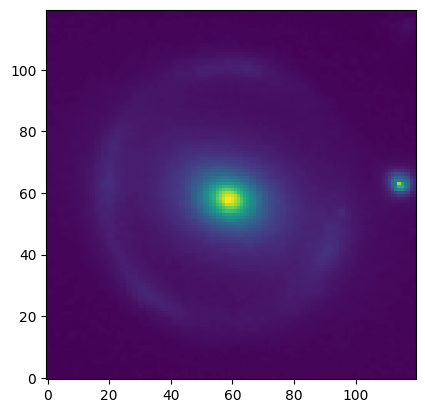

In [3]:
observed_img = np.load("system65.npy")
observed_img = observed_img[15:135, 10:130]
plt.imshow(observed_img, cmap="viridis", origin='lower')
print(observed_img.shape)

In [4]:
kernel = np.load("psf65.npy").astype(np.float32)
sim_config = SimulatorConfig(delta_pix=0.065, num_pix=120, supersample=1, kernel=kernel)
n_max=6
phys_model = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=True),sersic.SersicEllipse(use_lstsq=True),sersic.SersicEllipse(use_lstsq=True),sersic.SersicEllipse(use_lstsq=True)], [sersic.SersicEllipse(use_lstsq=True),shapelets.Shapelets(n_max=n_max, use_lstsq=True, interpolate=False)])
phys_model_forward = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=False),sersic.SersicEllipse(use_lstsq=False),sersic.SersicEllipse(use_lstsq=False),sersic.SersicEllipse(use_lstsq=False)], [shapelets.Shapelets(n_max=n_max, use_lstsq=False, interpolate=False)])
lens_sim = LensSimulator(phys_model, sim_config, bs=1)
background_rms = 0.008230474
exp_time = 1197.699462
prob_model = BackwardProbModel(prior, jnp.array(observed_img), background_rms=background_rms, exp_time=exp_time)
model_seq = ModellingSequence(phys_model, prob_model, sim_config)

In [5]:
# opt = optax.adabelief(1e-2, b1=0.95, b2=0.99, nesterov=True)
# best, lps, chisq = model_seq.MAP(opt, seed=0, n_samples=100, num_steps=3000)

In [6]:
# norm = simple_norm(observed_img, "sqrt", percent=99.)
# physical = prob_model.bij.forward(list(best.T))
# print(physical)
# err_map = np.sqrt(background_rms**2 + observed_img/exp_time)
# simulated = lens_sim.lstsq_simulate(physical, jnp.array(observed_img), err_map)[0]
# plt.imshow(simulated, norm=norm, cmap="viridis", origin='lower')

In [7]:
# schedule_fn = optax.polynomial_schedule(init_value=1e-3, end_value=1e-6,
#                                         power=0.5, transition_steps=1000)
# opt = optax.adabelief(schedule_fn, b1=0.95, b2=0.99)
# qz, loss_hist = model_seq.SVI(best, opt, n_vi=1000, num_steps=1250, init_scales=1e-2)
# plt.plot(loss_hist)

In [8]:
qz = jnp.load("qz.npz")
qz = tfd.MultivariateNormalTriL(loc=qz['loc'], scale_tril=qz['scale_tril'])

In [9]:
import nuts_multi_2
from importlib import reload
reload(nuts_multi_2)
nuts_samples = nuts_multi_2.NUTS(model_seq, qz, n_chains=16, num_burnin_steps=100, num_results=100, target_acceptance_rate=0.8)

Starting burnin


2026-04-03 15:38:59.693851: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-04-03 15:38:59.693983: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-04-03 15:38:59.694012: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-04-03 15:38:59.694039: W external/xla/xla/service/gpu/au

Burnin took 2745.3s
Sampling took 3469.6s


In [14]:
smp = nuts_samples.reshape(-1, 41)
smp_physical = prob_model.bij.forward(list(smp.T))
tups = [(0, 0), (0, 1), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1)]
label_prefixes = ["", "", "other1_", "other2_", "lens1_", "lens2_", "src_sersic_", "src_shape_"]
labels = []
for (i, j), label_prefix in zip(tups, label_prefixes):
    labels.extend((label_prefix + key for key in smp_physical[i][j].keys()))
median_params = [
    [
        {key: np.median(value) for key, value in d.items()}
        for d in list_of_dicts
    ]
    for list_of_dicts in smp_physical
]
print(median_params)

plt.style.use('default')
plt_samples = np.vstack(
    [np.array(list(smp_physical[i][j].values())) for i, j in tups]
).T
print(plt_samples.shape)

fig = corner.corner(
    plt_samples,
    show_titles=True,
    title_fmt=".3f",
    labels=labels
)
plt.savefig("cornerplot.png")
plt.show()

[[{'theta_E': np.float32(2.6254573), 'gamma': np.float32(1.6958356), 'e2': np.float32(-0.12471042), 'e1': np.float32(0.11129928), 'center_y': np.float32(-0.13423647), 'center_x': np.float32(-0.037538957)}, {'gamma2': np.float32(-0.0575365), 'gamma1': np.float32(0.030801263)}], [{'n_sersic': np.float32(1.3538749), 'e2': np.float32(-0.0025778562), 'e1': np.float32(0.1351113), 'center_y': np.float32(0.17323431), 'center_x': np.float32(3.5350852), 'R_sersic': np.float32(0.16101184)}, {'n_sersic': np.float32(1.4410977), 'e2': np.float32(-0.06426039), 'e1': np.float32(0.14980194), 'center_y': np.float32(0.14133874), 'center_x': np.float32(3.4906418), 'R_sersic': np.float32(0.16489047)}, {'n_sersic': np.float32(0.9235133), 'e2': np.float32(-0.024892176), 'e1': np.float32(0.12045304), 'center_y': np.float32(-0.08124761), 'center_x': np.float32(-0.052541174), 'R_sersic': np.float32(0.4449823)}, {'n_sersic': np.float32(1.894942), 'e2': np.float32(-0.18484008), 'e1': np.float32(0.15518583), 'cent

In [11]:
samples_np = np.array(nuts_samples)  # convert from JAX to NumPy
np.save("nuts_samples.qzy", samples_np)

In [13]:
blackjax.diagnostics.potential_scale_reduction(nuts_samples, chain_axis=0, sample_axis=1)

Array([7.7484216e+02, 7.8650446e+02, 7.7841309e+02, 1.0569889e+03,
       1.4004259e+04, 1.7562042e+02, 9.4914471e+02, 7.3952924e+02,
       1.5768920e+05, 2.1433656e+04, 1.0583502e+03, 7.3938164e+04,
       1.7617787e+04, 1.2776475e+06, 4.3853281e+05, 3.8274816e+04,
       1.1503546e+03, 1.8915170e+06, 4.0793734e+04, 1.5815465e+06,
       4.3654595e+03, 6.1879865e+02, 3.5357956e+02, 7.4890735e+02,
       1.1309015e+03, 2.9430647e+05, 4.3959624e+03, 9.1794482e+02,
       6.1479529e+02, 3.0816232e+02, 4.3544266e+02, 3.8195534e+05,
       3.6031383e+04, 7.0965947e+03, 5.5803804e+03, 2.4189443e+03,
       6.1315693e+03, 5.2462450e+06, 2.2333506e+05, 1.4064584e+03,
       9.3498492e+02], dtype=float32)